# Modelagem e Avaliação (v6)
## v4 vs v6 — Histórico de Copas como Feature

**Hipótese:** O desempenho histórico em Copas anteriores captura informação sobre tradição e consistência que as features de ciclo não capturam.

| | v4 | v6 |
|--|----|----|  
| Features | 9 | 11 |
| Amostras treino | 216 | 216 |
| Histórico Copas | ❌ | ✅ |

## 1. Imports e Carregamento

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor
from scipy.stats import wilcoxon
from sklearn.base import clone
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid')
np.random.seed(42)

df_v4 = pd.read_csv('../data/processed/features_completo_v4.csv')
df_v6 = pd.read_csv('../data/processed/features_completo_v6.csv')

print(f'v4: {df_v4.shape} | v6: {df_v6.shape}')

v4: (248, 12) | v6: (248, 14)


## 2. Definição das Features e Divisão

In [13]:
features_v4 = [
    'media_gols_marcados_ciclo', 'media_gols_sofridos_ciclo',
    'pct_vitorias_ciclo', 'total_jogos_ciclo',
    'media_gols_marcados_ult15', 'media_gols_sofridos_ult15',
    'pct_vitorias_ult15', 'elo_medio_adv_ciclo', 'elo_medio_adv_ult15'
]

features_v6 = features_v4 + [
    'media_gols_ultimas2_copas', 'fase_ultima_copa'
]

def dividir(df, features):
    X_tr = df[df['copa_alvo'] < 2022][features]
    X_te = df[df['copa_alvo'] == 2022][features]
    y_tr = df[df['copa_alvo'] < 2022]['media_gols_copa']
    y_te = df[df['copa_alvo'] == 2022]['media_gols_copa']
    return X_tr, X_te, y_tr, y_te

X_tr4, X_te4, y_tr4, y_te = dividir(df_v4, features_v4)
X_tr6, X_te6, y_tr6, _   = dividir(df_v6, features_v6)

print(f'Treino v4: {X_tr4.shape[0]} | Treino v6: {X_tr6.shape[0]}')
print(f'Teste: {X_te4.shape[0]} amostras (Copa 2022)')

Treino v4: 216 | Treino v6: 216
Teste: 32 amostras (Copa 2022)


## 3. Treino e Avaliação

In [14]:
resultados = []
modelos_v4 = {}
modelos_v6 = {}

configs = [
    ('Regressão Linear', LinearRegression()),
    ('Random Forest',    RandomForestRegressor(n_estimators=100, random_state=42)),
    ('XGBoost',          XGBRegressor(n_estimators=100, random_state=42))
]

for nome, base in configs:
    m4 = clone(base)
    m4.fit(X_tr4, y_tr4)
    pred4 = m4.predict(X_te4)
    modelos_v4[nome] = m4
    resultados.append({'Versão': 'v4', 'Modelo': nome,
        'MAE': mean_absolute_error(y_te, pred4),
        'RMSE': root_mean_squared_error(y_te, pred4), 'y_pred': pred4})

    m6 = clone(base)
    m6.fit(X_tr6, y_tr6)
    pred6 = m6.predict(X_te6)
    modelos_v6[nome] = m6
    resultados.append({'Versão': 'v6', 'Modelo': nome,
        'MAE': mean_absolute_error(y_te, pred6),
        'RMSE': root_mean_squared_error(y_te, pred6), 'y_pred': pred6})

df_res = pd.DataFrame(resultados).drop(columns='y_pred')
print('Comparação v4 vs v6 — Teste (Copa 2022):')
print(df_res.sort_values(['Modelo', 'Versão']).to_string(index=False))

Comparação v4 vs v6 — Teste (Copa 2022):
Versão           Modelo      MAE     RMSE
    v4    Random Forest 0.461028 0.568261
    v6    Random Forest 0.467693 0.563058
    v4 Regressão Linear 0.456479 0.551036
    v6 Regressão Linear 0.445965 0.534637
    v4          XGBoost 0.518548 0.621398
    v6          XGBoost 0.530287 0.627091


## 4. Visualização — MAE v4 vs v6

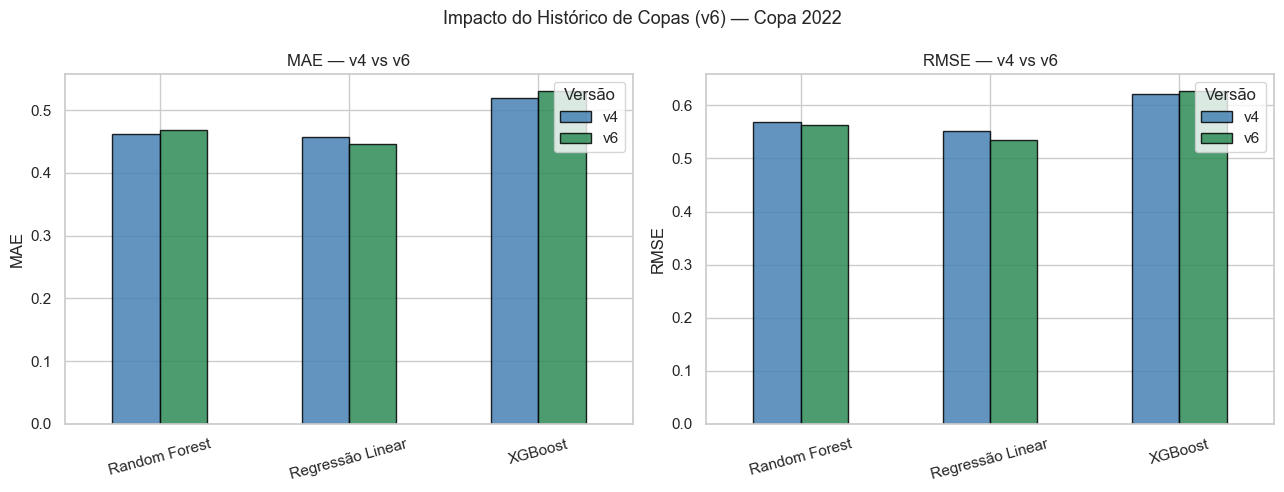

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica in zip(axes, ['MAE', 'RMSE']):
    pivot = df_res.pivot(index='Modelo', columns='Versão', values=metrica)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'seagreen'],
               edgecolor='black', alpha=0.85)
    ax.set_title(f'{metrica} — v4 vs v6')
    ax.set_ylabel(metrica)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Versão')

plt.suptitle('Impacto do Histórico de Copas (v6) — Copa 2022', fontsize=13)
plt.tight_layout()
plt.savefig('../article/figures/comparacao_v4_v6.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Validação Cruzada Temporal

In [16]:
copas_ord = sorted(df_v6['copa_alvo'].unique())
folds = [(copas_ord[:i], copas_ord[i]) for i in range(2, len(copas_ord))]

mae_cv = {'v4_LR': [], 'v4_RF': [], 'v4_XGB': [],
          'v6_LR': [], 'v6_RF': [], 'v6_XGB': []}

for copas_tr, copa_te in folds:
    for df_ver, feats, pref in [
        (df_v4, features_v4, 'v4'),
        (df_v6, features_v6, 'v6')
    ]:
        mask_tr = df_ver['copa_alvo'].isin(copas_tr)
        mask_te = df_ver['copa_alvo'] == copa_te
        Xtr = df_ver[mask_tr][feats]
        ytr = df_ver[mask_tr]['media_gols_copa']
        Xte = df_ver[mask_te][feats]
        yte = df_ver[mask_te]['media_gols_copa']

        for suf, base in [('LR', LinearRegression()),
                           ('RF', RandomForestRegressor(n_estimators=100, random_state=42)),
                           ('XGB', XGBRegressor(n_estimators=100, random_state=42))]:
            m = clone(base)
            m.fit(Xtr, ytr)
            mae_cv[f'{pref}_{suf}'].append(mean_absolute_error(yte, m.predict(Xte)))

nomes = {'LR': 'Reg. Linear', 'RF': 'Random Forest', 'XGB': 'XGBoost'}
print('Validação Cruzada Temporal — v4 vs v6:')
print(f'{"Versão/Modelo":<25} {"MAE Médio":>10} {"Std":>10}')
print('-' * 47)
for ver in ['v4', 'v6']:
    for suf in ['LR', 'RF', 'XGB']:
        chave = f'{ver}_{suf}'
        print(f'{ver} — {nomes[suf]:<20} {np.mean(mae_cv[chave]):>10.4f} {np.std(mae_cv[chave]):>10.4f}')

Validação Cruzada Temporal — v4 vs v6:
Versão/Modelo              MAE Médio        Std
-----------------------------------------------
v4 — Reg. Linear              0.4374     0.0464
v4 — Random Forest            0.4515     0.0523
v4 — XGBoost                  0.4923     0.0326
v6 — Reg. Linear              0.4443     0.0619
v6 — Random Forest            0.4451     0.0500
v6 — XGBoost                  0.5038     0.0557


## 6. Teste de Wilcoxon

In [17]:
print('Teste de Wilcoxon — v4 vs v6:')
for suf, nome in [('LR', 'Regressão Linear'), ('RF', 'Random Forest'), ('XGB', 'XGBoost')]:
    try:
        stat, p = wilcoxon(mae_cv[f'v4_{suf}'], mae_cv[f'v6_{suf}'])
        v4_mae = np.mean(mae_cv[f'v4_{suf}'])
        v6_mae = np.mean(mae_cv[f'v6_{suf}'])
        melhor = 'v6 ✅' if v6_mae < v4_mae and p < 0.05 else \
                 ('v6 (n.s.)' if v6_mae < v4_mae else 'v4')
        print(f'{nome}: MAE v4={v4_mae:.4f} | MAE v6={v6_mae:.4f} | p={p:.4f} | {melhor}')
    except Exception as e:
        print(f'{nome}: {e}')

Teste de Wilcoxon — v4 vs v6:
Regressão Linear: MAE v4=0.4374 | MAE v6=0.4443 | p=0.4375 | v4
Random Forest: MAE v4=0.4515 | MAE v6=0.4451 | p=0.1562 | v6 (n.s.)
XGBoost: MAE v4=0.4923 | MAE v6=0.5038 | p=0.4375 | v4


## 7. Importância de Features — v6

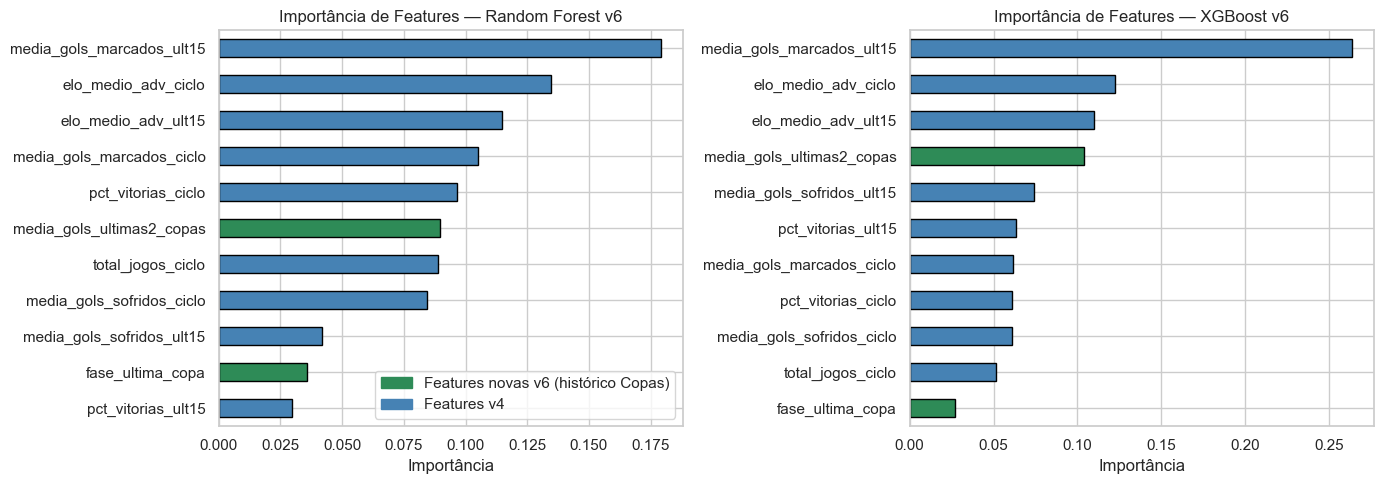

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (modelo, nome) in zip(axes, [
    (modelos_v6['Random Forest'], 'Random Forest v6'),
    (modelos_v6['XGBoost'],       'XGBoost v6')
]):
    imp = pd.Series(modelo.feature_importances_, index=features_v6).sort_values()
    novas = ['media_gols_ultimas2_copas', 'fase_ultima_copa']
    colors = ['seagreen' if f in novas else 'steelblue' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'Importância de Features — {nome}')
    ax.set_xlabel('Importância')

legend = [
    Patch(color='seagreen',  label='Features novas v6 (histórico Copas)'),
    Patch(color='steelblue', label='Features v4')
]
axes[0].legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('../article/figures/importancia_features_v6.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabela Final

In [19]:
resumo = pd.DataFrame({
    'Versão':  ['v4'] * 3 + ['v6'] * 3,
    'Modelo':  ['Regressão Linear', 'Random Forest', 'XGBoost'] * 2,
    'MAE Teste': [
        df_res[(df_res['Versão']=='v4') & (df_res['Modelo']==m)]['MAE'].values[0]
        for m in ['Regressão Linear', 'Random Forest', 'XGBoost']
    ] + [
        df_res[(df_res['Versão']=='v6') & (df_res['Modelo']==m)]['MAE'].values[0]
        for m in ['Regressão Linear', 'Random Forest', 'XGBoost']
    ],
    'MAE CV': [
        np.mean(mae_cv['v4_LR']), np.mean(mae_cv['v4_RF']), np.mean(mae_cv['v4_XGB']),
        np.mean(mae_cv['v6_LR']), np.mean(mae_cv['v6_RF']), np.mean(mae_cv['v6_XGB']),
    ],
    'Std CV': [
        np.std(mae_cv['v4_LR']), np.std(mae_cv['v4_RF']), np.std(mae_cv['v4_XGB']),
        np.std(mae_cv['v6_LR']), np.std(mae_cv['v6_RF']), np.std(mae_cv['v6_XGB']),
    ]
}).round(4)

print(resumo.to_string(index=False))
resumo.to_csv('../article/tables/comparacao_v4_v6.csv', index=False)
print('Salvo!')

Versão           Modelo  MAE Teste  MAE CV  Std CV
    v4 Regressão Linear     0.4565  0.4374  0.0464
    v4    Random Forest     0.4610  0.4515  0.0523
    v4          XGBoost     0.5185  0.4923  0.0326
    v6 Regressão Linear     0.4460  0.4443  0.0619
    v6    Random Forest     0.4677  0.4451  0.0500
    v6          XGBoost     0.5303  0.5038  0.0557
Salvo!


## 9. Conclusão

**Critério de decisão:**
- v6 MAE CV < v4 MAE CV **e** Wilcoxon p < 0.05 → **v6 é o modelo final**
- Diferença não significativa → v4 pelo princípio da parcimônia
- v6 piorou → v4 definitivamente

**Próximo passo:** Atualizar `04_previsao_2026` com o modelo vencedor.